import numpy for numerical. pandas for data handling matplotlib for graph and visualization. import other ml tools from sklearn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

load the social_network_ads dataset

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


independaent variable(feature) dependent variable(target)

In [4]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

treating dataet into training(80%) and testing(20%)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Scales data (mean=0, std=1)

Important for Logistic Regression

In [7]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

train logistic regreassion model. Model learns relationship between Age, Salary → Purchased

In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Prediction Model predicts whether user will purchase or not

In [9]:
y_pred = model.predict(X_test)

Accuracy → overall correctness

Precision → correct positive predictions

Recall → how many actual positives detected

Confusion Matrix → model performance breakdown

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Error Rate: {error_rate* 100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Confusion Matrix:
 [[57  1]
 [ 5 17]]
TP: 17
FP: 1
TN: 57
FN: 5
Accuracy: 92.50%
Accuracy: 92.50%
Error Rate: 7.50%
Precision: 94.44%
Recall: 77.27%


checks the null values in the dataset

In [11]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

missing values visualization

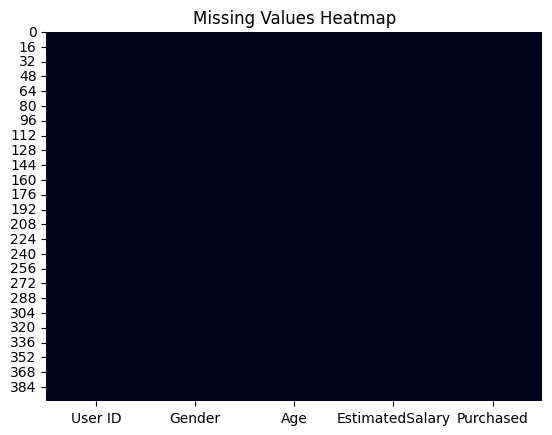

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Dataset information Info → datatype, null values

Describe → mean, std, min, max

In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


Shows how many people purchased vs not

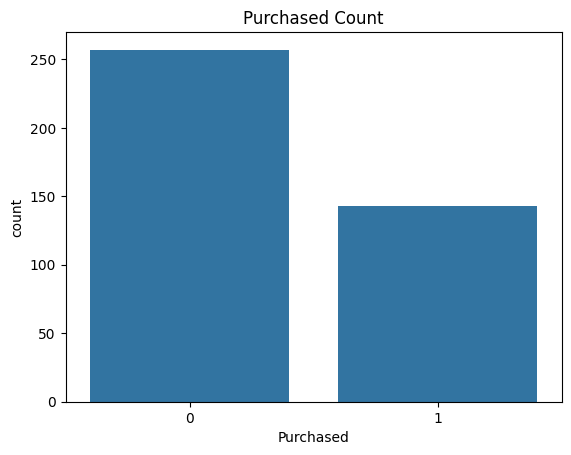

In [14]:
sns.countplot(x='Purchased', data=df)
plt.title("Purchased Count")
plt.show()

show data visualization (historogram)

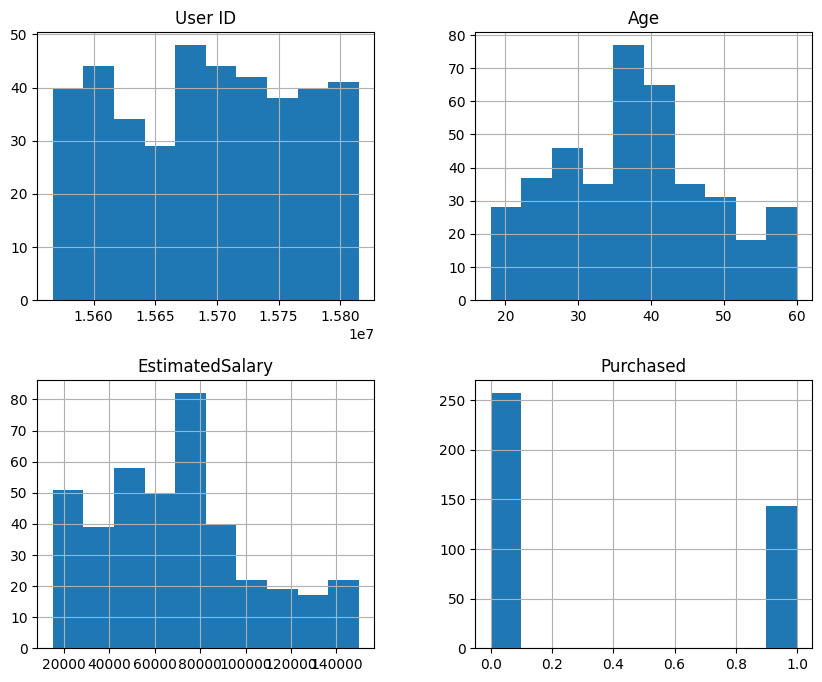

In [16]:
df.hist(figsize=(10,8))
plt.show()